<a href="https://colab.research.google.com/github/evgeny-kolonsky/IMU/blob/main/Inertial_sensors_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Planning kinematic experiments with intertial motion sensors

v0.1.1

Valery Etingov, Evgeny Kolonsky 2026




We have a microchip (specifically [XIAO nRF52840](https://wiki.seeedstudio.com/XIAO_BLE/)), having small weight (~ 5g) and small size dimensions (~20 x 18 x 6 mm with battery). This chip is equipped with **Inertial Motion Unit** (IMU). IMU sensors are  built-in 3-axis accelerometer and 3-axis gyroscope. The accelerometer returns acceleration $(a_x, a_y, a_z)$, gyroscope returns angular velocity $(\omega_x, \omega_y, \omega_z)$. All data is measured in body-fixed non-inertial reference system of the chip. The data can be passed for analysis by wire or wireless.

The idea is to use this chip attached to a moving body to understand better what happens in a simple mechanical experiments in undergraduate teaching labs.

Say, in Lab1m students are performing **Collision experiment**. In this experiment a moving ball hits the other ball in rest, and scattering angle is measured. When balls are modelled as a point masses, it is expected out of energy and momentum conservation laws that for any collision angle the scattering angle with be 90 degrees. Actually the scattering angle measured differs significantly. This behaviour could be explained by more complex model, assuming collision inealstity and spin exchange. Collision observation with fast digital camera gives rather good  understanding of coordinates and linear velocities, but does not help understand rolling and spinning values. The IMU chip with gyroscope would help.

The other example is Lab1m **Rolling experiment**. The heavy ball is rolling on inclined U-shaped track. The final velocity is expected out of energy coservation law.  Again, actual results differ from expectations. We might assume that the reason is ball slipping and write motion equations for this case. The model validity might be experimentally checked with IMU sensors built into the ball.

Working with kinematic data from IMU sensors requires a deep understanding of the technology's limitations. The data is numeric, noisy, and measured in a body-fixed coordinate system. Brute-force conversion to a lab coordinate system leads to rapid error accumulation.

Here are the experiments we plan to do to achieve better understanding.

# Getting know the measuremenent device and the readings interface




## How the IMU accelerometer works?

A proof mass $m$ hanging on elastic spings under acceleration $a$ displacement $d$. Dsiplacement, and hence acceleration value is  measured as change in electric capacitance.
$$
m a_x = k d.
$$

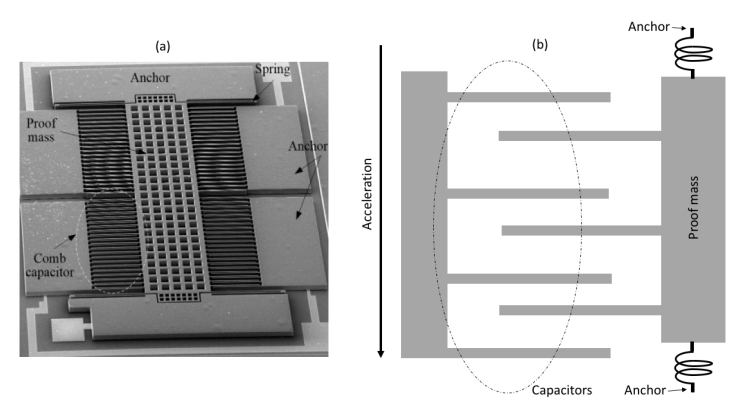

[image source](https://www.researchgate.net/publication/337827590_Deep_Learning_for_Abnormal_Movement_Detection_using_Wearable_Sensors_Case_Studies_on_Stereotypical_Motor_Movements_in_Autism_and_Freezing_of_Gait_in_Parkinson's_Disease)

Specification:
- Range $\pm 2, \pm 4, \pm 8, \pm 16 g$.
- Resolution 16 bit (range divided by 65536).
- Readings frequency up to 6660 Hz.

## How the IMU gyroscope works?

Motion of a mass in $y$-axis is created by vibrating mechanical element. When mass $m$ is moving with velocity $v_y$ in a coordinate system rotating with angular velocity $\omega_x$ (shown as $\Omega$ on the figure) the mass gets acceleration $a_z$ due to Corilolis forces effect:
$$
a_z = 2  v_y \times \omega_x.
$$
The displacement du to the Coriolis effect is measured as a change in electric capacitance.

![gyro](https://www.researchgate.net/profile/Nastaran-Mohammadian-Rad/publication/337827590/figure/fig3/AS:833912649576448@1575831677051/a-The-Coriolis-acceleration-3-b-The-schematic-of-MEMS-gyroscope-with-the.ppm)

[image source](https://www.researchgate.net/publication/337827590_Deep_Learning_for_Abnormal_Movement_Detection_using_Wearable_Sensors_Case_Studies_on_Stereotypical_Motor_Movements_in_Autism_and_Freezing_of_Gait_in_Parkinson's_Disease)

Specification:
- Range:  $\pm 125 \dots \pm 2000$ degrees per second.
- Resolution: 16 bit (range divided by 65536).
- Readings frequency: up to 1660 Hz.

## Computer interface

The computer interface consists of two parts: one works on the chip, the other works on the computer. The data and commands are transferred between the chip and the computer via USB by wire or via BLE wireless. Wireless transfer is relatively slow.

The IMU **chip firmware** was created using Claude AI assistant. It has built-in parameters, e.g. readings frequency (100 Hz by default) and readings maximum time. When we meet the problem requiring higher readings frequency, or longer readings time, we should recompile and reload the chip firmware.

The **computer application** also was created by Claude AI assistant. It can work via USB or via BLE. The main functions are:
- sending command to start measurements;
- fetchning the data from the chip to the computer, plotting result on a graph. In USB mode it works on-the-fly. In BLE mode due to slow bandwidth it works post-factum.
- downloading data to CSV for further analysis;
- working in dual BLE mode with two chips simultaneously.


## 1. Static calibration

Keep chip static for few seconds.
- Get acceleration vector and compare with known $g$ by value and direction. Calculate orientation angles. Estimate uncertainties of acceleration. Calibrate.
- Get angular velocites. It should be zero. Calibrate.



## 2.1 1D harmonic motion on air-track

Attach the chip to a cart of the airtrack system (lab1h).
Using forced oscillation generator, produce stationary harmonic motion $x(t) = A \cos\omega t$. The acceleration in this case is expected to be $a(t) = \ddot x(t) = A \omega^2 \cos\omega t$ one-dimensional and harmonic. Compare frequency and oscillations acceleration data of the KRUZE and built-in inertial sensor


## 2.2 1D harmonic motion on a physical pendulum

Attach the chip to the physical pendulum and push it. Measure period by stopper. Download data and observe periodic changes of acceleration. Fit frequency and compare with value measured directly.  

https://github.com/evgeny-kolonsky/IMU/tree/main/pendulum




## 3. 1D rolling without slipping on inclined plane

Attach the chip to a massive disk with radius $R$. The disk is rolling down on a inclined plane, inclination angle $\alpha$. Measure velocity with camera. Get acceleration and angular velocity. The acceleration should be $a = g \sin\alpha$. The angular velocity when no slipping should be $\omega = \frac{v}{R}$



## 4.1 2D disk free motion on air-table

Attach the chip to a disk. Measure cooridnates and velocities with digital camera. Measure angular rotation velocity. If the table is perfectly horizontal, the disk should have constant velocity and angular velocity between collisions.

https://github.com/evgeny-kolonsky/IMU/tree/main/airhockey

## 4.2 2D disks motion on air-table with collision

Attach the chips to disk A and disk B. Again, use digital camera.Perform central collision. Find elastity coeffecient $e$ (smth between 0 and 1). Add spin rotation to a disk A. Perform central collision and find friction coefficient $\mu$. Perform series on non-central collisions. Measure scattering angle and compare with scattering angle expected

https://github.com/evgeny-kolonsky/IMU/tree/main/airhockey/dual


## 5. 2D balls collisions

Make massive balls with built-in IMU sensor chips. Use digital camera to measure velocities.Perform series of measurements with balls, as in 4.2 with disks on the airtable. Measure scattering angle and compare with expected.



## 6. Nice spin-off: The Janibekov effect

[video](https://youtu.be/1VPfZ_XzisU)

if the body has inertial moments $J_x < J_y < J_z$, then rotation around the biggest $J_z$ and the smallest $J_x$ inertia axis is stable, and the rotation around inermediate axis $J_y$ is unstable. The handy example of such a body is A4 workbook. It can be easily seen in body-fixed coordinate system. We can simply put the IMU chip into the workbook, throw it up and enjoy the effect.

https://github.com/evgeny-kolonsky/IMU/tree/main/janibekov

